# These commands are helpful to see astroquery version and relevant steuptools


In [47]:
#import pkg_resources
#print(pkg_resources.__file__)
#pip install setuptools
#import sys
#print(sys.executable)
#print(sys.version)

In [229]:
from astroquery.alma import Alma
import os
import numpy as np
import pandas as pd
from astroquery.alma.utils import parse_frequency_support
import astropy.units as u
from astropy.table import Table
import shutil
from pathlib import Path
import tarfile
from astropy.io import fits
from spectral_cube import SpectralCube
import matplotlib.pyplot as plt 
import alminer
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import add_beam

# These are the same keywords on the ALMA Archive: 1) Disks around low-mass stars, 2) Low mass star formation, 3) Outflows, jets, and ionized winds

In [213]:

# Give me all columns from the database. We are searching rowns with ALMA metadata
alma = Alma()
alma.archive_url = 'https://almascience.eso.org'
#query = """
#SELECT *
#FROM ivoa.obscore
#WHERE science_keyword LIKE '%Outflows, jets and ionized winds%'
#"""

In [214]:
#Used ALMA astroTAP query to find the data products with observation keywords stored in ALMA data
query = """
SELECT
    obs_publisher_did,
    member_ous_uid,
    target_name,
    frequency_support,
    science_keyword
FROM ivoa.obscore
WHERE dataproduct_type = 'cube'
AND (
      science_keyword LIKE '%jets and ionized winds%'
      
    
  )
"""

In [215]:
#This results have all the data products
results = alma.query_tap(query)

In [216]:
pd.DataFrame(results)

,obs_publisher_did,member_ous_uid,target_name,frequency_support,science_keyword
0,ADS/JAO.ALMA#2013.1.00465.S,uid://A001/X148/X4e,J0438+3004,"[215.50..217.49GHz,31250.00kHz,1.6mJy/beam@10k...","Outflows, jets and ionized winds;Low-mass star..."
1,ADS/JAO.ALMA#2013.1.00465.S,uid://A001/X148/X4e,J0438+3004,"[215.50..217.49GHz,31250.00kHz,1.6mJy/beam@10k...","Outflows, jets and ionized winds;Low-mass star..."
2,ADS/JAO.ALMA#2013.1.00465.S,uid://A001/X148/X4e,J041847,"[215.50..217.49GHz,31250.00kHz,1mJy/beam@10km/...","Outflows, jets and ionized winds;Low-mass star..."
3,ADS/JAO.ALMA#2013.1.00465.S,uid://A001/X148/X4e,J041847,"[215.50..217.49GHz,31250.00kHz,1mJy/beam@10km/...","Outflows, jets and ionized winds;Low-mass star..."
4,ADS/JAO.ALMA#2013.1.00465.S,uid://A001/X148/X4e,J041836,"[215.50..217.49GHz,31250.00kHz,1mJy/beam@10km/...","Outflows, jets and ionized winds;Low-mass star..."
...,...,...,...,...,...
31584,ADS/JAO.ALMA#2025.1.00515.S,uid://A001/X3922/X4dd,J2207-5346,"[226.62..228.60GHz,31250.00kHz,1.2mJy/beam@10k...","Outflows, jets and ionized winds;Inter-Stellar..."
31585,ADS/JAO.ALMA#2025.1.00515.S,uid://A001/X3922/X4d7,J1339-2620,"[225.41..225.88GHz,1128.91kHz,1.3mJy/beam@10km...","Outflows, jets and ionized winds;Inter-Stellar..."
31586,ADS/JAO.ALMA#2025.1.00515.S,uid://A001/X3922/X4d7,J1427-4206,"[225.41..225.87GHz,1128.91kHz,1.3mJy/beam@10km...","Outflows, jets and ionized winds;Inter-Stellar..."
31587,ADS/JAO.ALMA#2025.1.00515.S,uid://A001/X3922/X4d7,J1351-2912,"[225.41..225.88GHz,1128.91kHz,967.8uJy/beam@10...","Outflows, jets and ionized winds;Inter-Stellar..."


In [217]:

#print(results)

# Parse the frequency support in the ALMA Data

In [218]:
#Freuency support stored as string so need to parse frequncy and only need frequncy ranges
frequency_support_str = results['frequency_support'][0]
print(frequency_support_str)

[215.50..217.49GHz,31250.00kHz,1.6mJy/beam@10km/s,97uJy/beam@native, XX YY] U [218.55..220.43GHz,1128.91kHz,1.6mJy/beam@10km/s,100.3uJy/beam@native, XX YY] U [230.51..230.97GHz,282.23kHz,1.6mJy/beam@10km/s,201.8uJy/beam@native, XX YY] U [231.80..233.79GHz,31250.00kHz,1.6mJy/beam@10km/s,97.8uJy/beam@native, XX YY]


In [219]:
#Parse the frequncy support
freq_ranges = parse_frequency_support(frequency_support_str)
print(freq_ranges)

[[215.5  217.49]
 [218.55 220.43]
 [230.51 230.97]
 [231.8  233.79]] GHz


In [220]:
# Set up frequency range and in results find the range

#min_window = 346.9 * u.GHz
#max_window = 347.8 * u.GHz
sio_rest = 347.33 * u.GHz

matches = [] #Empty list

for x in results:
    ranges = parse_frequency_support(x['frequency_support'])

    for fmin, fmax in ranges:
        if sio_rest >= fmin and sio_rest <= fmax:
            matches.append(x)
            break
#print(len(matches))

In [221]:
#convert results to a table
table = results.to_table()

In [222]:
#print columnames
table.colnames

['obs_publisher_did',
 'member_ous_uid',
 'target_name',
 'frequency_support',
 'science_keyword']

In [223]:
# Convert list to a astropy.table
matches = Table(rows=matches, names=table.colnames)
print(len(matches))

1313


In [224]:
print(matches[0])

     obs_publisher_did          member_ous_uid    target_name                                                                                                                                                                                                                                 frequency_support                                                                                                                                                                                                                                            science_keyword           
--------------------------- --------------------- ----------- ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [225]:
print(matches['member_ous_uid'][0])

uid://A001/X3621/X996


In [226]:
uid = matches['member_ous_uid'][0]

products = alma.get_data_info (uid,expand_tarfiles=True)

print(products)

                        ID                         ... link_authorized
                                                   ...                
-------------------------------------------------- ... ---------------
                             uid://A001/X3621/X996 ...            True
                             uid://A001/X3621/X996 ...            True
                             uid://A001/X3621/X996 ...            True
                             uid://A001/X3621/X996 ...            True
                             uid://A001/X3621/X996 ...            True
                             uid://A001/X3621/X996 ...            True
                             uid://A001/X3621/X996 ...            True
                             uid://A001/X3621/X996 ...            True
                             uid://A001/X3621/X996 ...            True
                                               ... ...             ...
2023.1.01515.S_uid___A001_X3621_X996_auxiliary.tar ...            True
2023.1

In [167]:

science_tar = products[
    [('001_of_001.tar' in str(x)) for x in products['access_url']]
]

#print(len(science_tar))
#print(scince_tar)

In [198]:
cube_files = []

for row in products:
    if 'cube' in str(row).lower() and '.fits' in str(row).lower():
        cube_files.append(row)
        print(row)

for x in cube_files:
    print(x)

                         ID                                                                      access_url                                             service_def error_message semantics local_semantics                      description                             content_type       content_length content_qualifier link_auth link_authorized
                                                                                                                                                                                                                                                                                                 byte                                                 
--------------------------------------------------- --------------------------------------------------------------------------------------------------- ----------- ------------- --------- --------------- ------------------------------------------------------ ------------------------ -------------- ---------------

In [ ]:
downloaded_files = alma.download_files(
    [row['access_url'] for row in cube_files]
)

In [177]:
alma.cache_location = '/users/skaur/Machine-Learning-Project/Astromorph_project/alma_astroquery/alma_TAP' #save fits file to that location
download_dir = Path("alma_TAP")
download_dir.mkdir(exist_ok=True)

# Check available columns
#print(cube_files.colnames)

# Download selected files
downloaded_files = alma.download_files(
    [row['access_url'] for row in cube_files]
)

# Move files
for f in downloaded_files:
    shutil.move(f, download_dir / Path(f).name)

In [151]:
#Alma.help_tap()

In [178]:
for f in download_dir.glob("*.fits"):
    if "cube" in f.name.lower():
        header = fits.getheader(f)

        print("\n", f.name)
        print("Rest frequency:", header.get("RESTFRQ", "No RESTFRQ"))


 member.uid___A001_X3621_X996.DHNb73_sci.spw27.cube.I.sd.fits
Rest frequency: 356734242000.0

 member.uid___A001_X133d_X3488._G328.2551-0.5321_A__sci.spw27.cube.I.pbcor.fits
Rest frequency: 346237500000.0

 member.uid___A001_X3621_X996.DHNb73_sci.spw21.cube.I.sd.fits
Rest frequency: 347330578600.0

 member.uid___A001_X3621_X996.DHNb73_sci.spw23.cube.I.sd.fits
Rest frequency: 346998347000.0

 member.uid___A001_X3621_X996.DHNb73_sci.spw25.cube.I.sd.fits
Rest frequency: 357050000000.0

 member.uid___A001_X3621_X996.DHNb73_sci.spw17.cube.I.sd.weight.fits
Rest frequency: 345795990000.0

 member.uid___A001_X3621_X996.DHNb73_sci.spw19.cube.I.sd.fits
Rest frequency: 345609010000.0

 member.uid___A001_X3621_X996.DHNb73_sci.spw25.cube.I.sd.weight.fits
Rest frequency: 357050000000.0

 member.uid___A001_X3621_X996.DHNb73_sci.spw17.cube.I.sd.fits
Rest frequency: 345795990000.0

 member.uid___A001_X3621_X996.DHNb73_sci.spw27.cube.I.sd.weight.fits
Rest frequency: 356734242000.0

 member.uid___A001_X

In [192]:
#Use rest frequency to find the right sio cube fits file
sio_file = None

for f in download_dir.glob("*.fits"):

    header = fits.getheader(f)

    restfreq = header.get("RESTFRQ", header.get("RESTFREQ", None))

    if restfreq is not None:
        restfreq_GHz = restfreq / 1e9

        if 346.0 < restfreq_GHz < 347:
            sio_file = f
            break

print("SiO file:", sio_file)

SiO file: alma_TAP/member.uid___A001_X133d_X3488._G328.2551-0.5321_A__sci.spw27.cube.I.pbcor.fits


In [194]:
# Keep files with the same SPW

keep_files = []

for f in download_dir.glob("*.fits"):

    header = fits.getheader(f)

    file_spw = header.get("SPW", header.get("SPWID", None))

    if file_spw == spw:
        keep_files.append(f)


print("\nKeeping:")
for f in keep_files:
    print(f.name)


Keeping:
member.uid___A001_X3621_X996.DHNb73_sci.spw27.cube.I.sd.fits
member.uid___A001_X133d_X3488._G328.2551-0.5321_A__sci.spw27.cube.I.pbcor.fits
member.uid___A001_X3621_X996.DHNb73_sci.spw27.cube.I.sd.weight.fits


In [195]:
# Delete other FITS files
for f in download_dir.glob("*.fits"):
    if f not in keep_files:
        f.unlink()
        print("Deleted:", f.name)

Deleted: member.uid___A001_X3621_X996.DHNb73_sci.spw21.cube.I.sd.fits
Deleted: member.uid___A001_X3621_X996.DHNb73_sci.spw23.cube.I.sd.fits
Deleted: member.uid___A001_X3621_X996.DHNb73_sci.spw25.cube.I.sd.fits
Deleted: member.uid___A001_X3621_X996.DHNb73_sci.spw17.cube.I.sd.weight.fits
Deleted: member.uid___A001_X3621_X996.DHNb73_sci.spw19.cube.I.sd.fits
Deleted: member.uid___A001_X3621_X996.DHNb73_sci.spw25.cube.I.sd.weight.fits
Deleted: member.uid___A001_X3621_X996.DHNb73_sci.spw17.cube.I.sd.fits
Deleted: member.uid___A001_X3621_X996.DHNb73_sci.spw21.cube.I.sd.weight.fits
Deleted: member.uid___A001_X3621_X996.DHNb73_sci.spw23.cube.I.sd.weight.fits
Deleted: member.uid___A001_X3621_X996.DHNb73_sci.spw19.cube.I.sd.weight.fits


In [184]:
cube = SpectralCube.read(sio_file)

print(cube)

SpectralCube with shape=(3838, 540, 540) and unit=Jy / beam:
 n_x:    540  type_x: RA---SIN  unit_x: deg    range:   239.492015 deg:  239.506270 deg
 n_y:    540  type_y: DEC--SIN  unit_y: deg    range:   -53.971022 deg:  -53.962638 deg
 n_s:   3838  type_s: FREQ      unit_s: Hz     range: 345384416372.000 Hz:347257867108.161 Hz


In [185]:
cube.spectral_axis

<Quantity [3.45384416e+11, 3.45384905e+11, 3.45385393e+11, 3.45385881e+11,
           3.45386369e+11, 3.45386858e+11, 3.45387346e+11, 3.45387834e+11,
           3.45388322e+11, 3.45388811e+11, 3.45389299e+11, 3.45389787e+11,
           3.45390275e+11, 3.45390764e+11, 3.45391252e+11, 3.45391740e+11,
           3.45392229e+11, 3.45392717e+11, 3.45393205e+11, 3.45393693e+11,
           3.45394182e+11, 3.45394670e+11, 3.45395158e+11, 3.45395646e+11,
           3.45396135e+11, 3.45396623e+11, 3.45397111e+11, 3.45397599e+11,
           3.45398088e+11, 3.45398576e+11, 3.45399064e+11, 3.45399552e+11,
           3.45400041e+11, 3.45400529e+11, 3.45401017e+11, 3.45401505e+11,
           3.45401994e+11, 3.45402482e+11, 3.45402970e+11, 3.45403458e+11,
           3.45403947e+11, 3.45404435e+11, 3.45404923e+11, 3.45405412e+11,
           3.45405900e+11, 3.45406388e+11, 3.45406876e+11, 3.45407365e+11,
           3.45407853e+11, 3.45408341e+11, 3.45408829e+11, 3.45409318e+11,
           3.45409806e+11

In [186]:
cube = cube.with_spectral_unit(
    u.km/u.s,
    velocity_convention='radio'
)

In [187]:
cube

SpectralCube with shape=(3838, 540, 540) and unit=Jy / beam:
 n_x:    540  type_x: RA---SIN  unit_x: deg    range:   239.492015 deg:  239.506270 deg
 n_y:    540  type_y: DEC--SIN  unit_y: deg    range:   -53.971022 deg:  -53.962638 deg
 n_s:   3838  type_s: VRAD      unit_s: km / s  range:     -883.493 km / s:     738.649 km / s

In [188]:
mom0 = cube.moment(order=0)

#print(mom0)

In [227]:
mom8 = cube.max(axis = 0, how='ray')

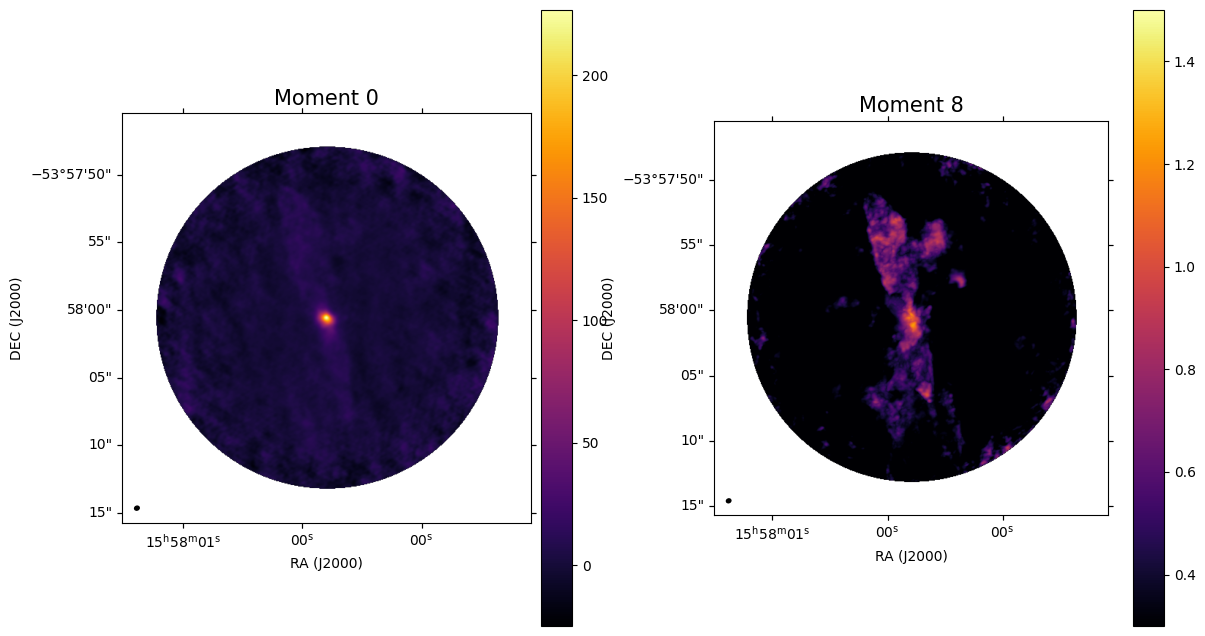

In [234]:
wcs_2d = mom0.wcs.celestial
fig = plt.figure(figsize=(14, 8))
ax0 = fig.add_subplot(1, 2, 1, projection=wcs_2d)
ax1 = fig.add_subplot(1, 2, 2, projection=wcs_2d)

img0= ax0.imshow(mom0.value, origin='lower',cmap = 'inferno')
img1 = ax1.imshow(mom8.value, origin='lower',cmap = 'inferno',vmin = 0.3, vmax = 1.5)

ax0.set_title('Moment 0',size = 15)
ax1.set_title('Moment 8',size = 15)
ax0.set_xlabel('RA (J2000)')
ax0.set_ylabel('DEC (J2000)')
ax1.set_xlabel('RA (J2000)')
ax1.set_ylabel('DEC (J2000)')
add_beam(ax0,
         header=cube.header,
         facecolor='black',
         edgecolor = 'black')

add_beam(ax1,
         header=cube.header,
         facecolor='black',
         edgecolor = 'black')
cbar0 = fig.colorbar(img0, ax = ax0, pad = 0.02)
cbar1 = fig.colorbar(img1, ax = ax1 )
#plt.savefig('NGC1333-IRAS2A_mom0_mom8_cube.png', dpi=300, bbox_inches='tight')
plt.show()